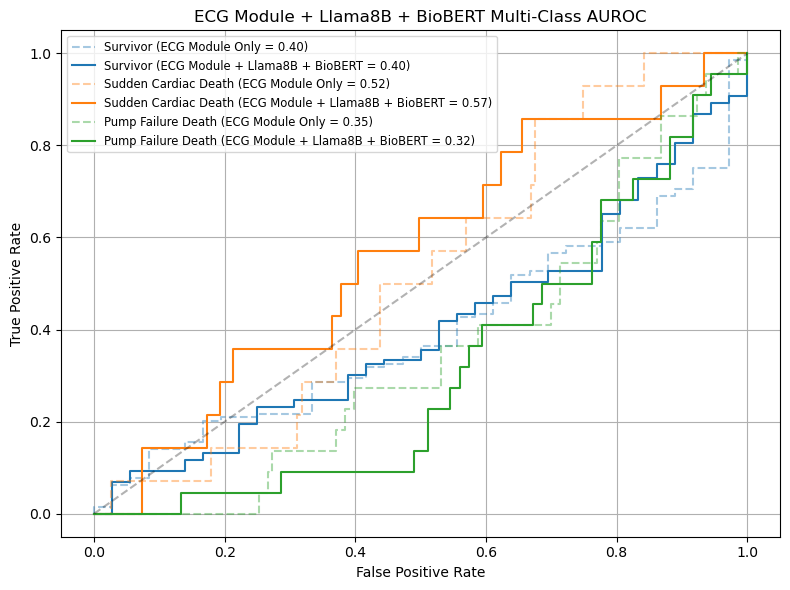

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load both datasets
df_current = pd.read_csv('Llama8BBioBERT_auroc_data.csv')
df_reference = pd.read_csv('ECGOnly_auroc_data.csv')

# Get unique classes
classes = df_current['class'].unique()

# Assign distinct colors to each class
colors = plt.cm.tab10.colors  # You can also try plt.cm.Set2, plt.cm.Dark2, etc.
color_map = {cls: colors[i % len(colors)] for i, cls in enumerate(classes)}

# Plotting
plt.figure(figsize=(8, 6))

for cls in classes:
    # Filter by class
    df_c = df_current[df_current['class'] == cls]
    df_r = df_reference[df_reference['class'] == cls]
    color = color_map[cls]

    # Plot reference (dimmer version of the same color)
    plt.plot(df_r['fpr'], df_r['tpr'], linestyle='--', color=color, alpha=0.4,
             label=f'{cls} (ECG Module Only = {df_r["auc"].iloc[0]:.2f})')

    # Plot current
    plt.plot(df_c['fpr'], df_c['tpr'], linestyle='-', color=color, alpha=1.0,
             label=f'{cls} (ECG Module + Llama8B + BioBERT = {df_c["auc"].iloc[0]:.2f})')

# Axis and legend
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ECG Module + Llama8B + BioBERT Multi-Class AUROC')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.savefig('ECG_Llama8B_BioBERT_AUROC.png', format='png', dpi=300)
plt.savefig('ECG_Llama8B_BioBERT_AUROC.svg', format='svg')
plt.show()
